In [18]:
import os
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'tick.minor':False,
    'savefig.dpi':300,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'legend.fontsize':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal'})

In [4]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']    
PREDSDIR   = CONFIGS['filepaths']['predictions']
MODELS     = CONFIGS['experiments']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
SPLIT      = 'valid'

In [ ]:
def load(splitsdir):
    train = xr.open_dataset(f'{SPLITSDIR}/train.h5',engine='h5netcdf')[['tp','pr']].load()
    valid = xr.open_dataset(f'{SPLITSDIR}/valid.h5',engine='h5netcdf')[['tp','pr']].load()
    era5  = xr.concat([train.tp,valid.tp],dim='time')#/3.0
    imerg = xr.concat([train.pr,valid.pr],dim='time')
    era5,imerg = xr.align(era5,imerg,join='inner')
    return era5,imerg

def flatten(a,b):
    a,b  = a.values.ravel(),b.values.ravel()
    mask = np.isfinite(a)&np.isfinite(b)
    return a[mask],b[mask]

def fit_empirical_qm(a,b,nquantiles=2000,eps=1e-8):
    adry,bdry = np.mean(a<=0),np.mean(b<=0)
    apos,bpos = a[a>0],b[b>0]
    quantiles = np.linspace(0,1,nquantiles)
    aq = np.quantile(apos,quantiles) if len(apos)>0 else np.array([0.])
    bq = np.quantile(bpos,quantiles) if len(bpos)>0 else np.array([0.])
    aq = np.maximum.accumulate(aq)
    bq = np.maximum.accumulate(bq)
    def qm(x):
        x   = np.maximum(np.asarray(x,float),0)
        out = np.zeros_like(x)
        out[x<=0] = 0
        out[x>0]  = np.interp(x[x>0],aq,bq,left=bq[0],right=bq[-1])
        return out
    return qm

def plot_distributions(era5flat,imergflat,mapped):
    fig,axs = pplt.subplots(nrows=1,ncols=3,refwidth=2,share=False)
    axs[0].format(xlabel='Precipitation Rate (mm/hr)',xlim=(0,140),xticks=20,
                  ylabel='PDF',yscale='log',yformatter='log',ylim=(1e-8,1e0))
    axs[1].format(xlabel='Precipitation Rate (mm/hr)',xlim=(1e-8,1e2),xscale='log',xformatter='log',
                  ylabel='Probability of Exceedance',ylim=(1e-8,1e0),yscale='log',yformatter='log')
    axs[2].format(xlabel='ERA5 Quantiles',ylabel='Quantile Error')
    allvals = np.concatenate([era5flat,imergflat,mapped])
    bins    = np.linspace(0,np.nanmax(allvals),50)
    axs[0].hist(era5flat,bins=bins,density=True,alpha=0.5,label='ERA5')
    axs[0].hist(imergflat,bins=bins,density=True,alpha=0.5,label='IMERG V06')
    axs[0].hist(mapped,bins=bins,density=True,alpha=0.5,label='QM-ERA5')
    axs[0].legend(loc='ur',ncols=1)
    def exceed(x):
        x = np.sort(x)
        y = 1-np.arange(1,len(x)+1)/len(x)
        return x,y
    x1,y1 = exceed(era5flat)
    x2,y2 = exceed(imergflat)
    x3,y3 = exceed(mapped)
    axs[1].plot(x1,y1,label='ERA5')
    axs[1].plot(x2,y2,label='IMERG V06')
    axs[1].plot(x3,y3,label='QM-ERA5')
    q = np.linspace(0.01,0.99,200)
    era5q   = np.quantile(era5flat,q)
    imergq  = np.quantile(imergflat,q)
    mappedq = np.quantile(mapped,q)
    qerr    = imergq-mappedq
    axs[2].plot(q,qerr,linewidth=2)
    axs[2].axhline(0,color='k',linestyle='--')

def plot_qm_sensitivity(era5flat,imergflat,nqlist=[50,100,200,500],tailpct=99,figpath=None):
    era5pos = era5flat[era5flat>0]
    tail    = np.quantile(era5pos,tailpct/100)
    xeval   = np.linspace(0,era5pos.max(),1000)
    fig,ax  = pplt.subplots(figwidth=4)
    ax.format(xlabel='ERA5 Precipitation Rate (mm/hr)',
              ylabel='IMERG V06 Precipitation Rate (mm/hr)')
    for nq in nqlist:
        qmfn = fit_empirical_qm(era5flat,imergflat,nquantiles=nq)
        ax.plot(xeval,qmfn(xeval),label=f'{nq} quantiles',linewidth=1.5)
    ax.axvspan(tail,era5pos.max(),color='gray',alpha=0.2,label=f'>{tailpct}th pctile',zorder=0)
    ax.axvline(tail,color='gray',linestyle=':',linewidth=1)
    ax.legend(loc='ul',ncols=1)

In [6]:
era5,imerg = load(SPLITSDIR)

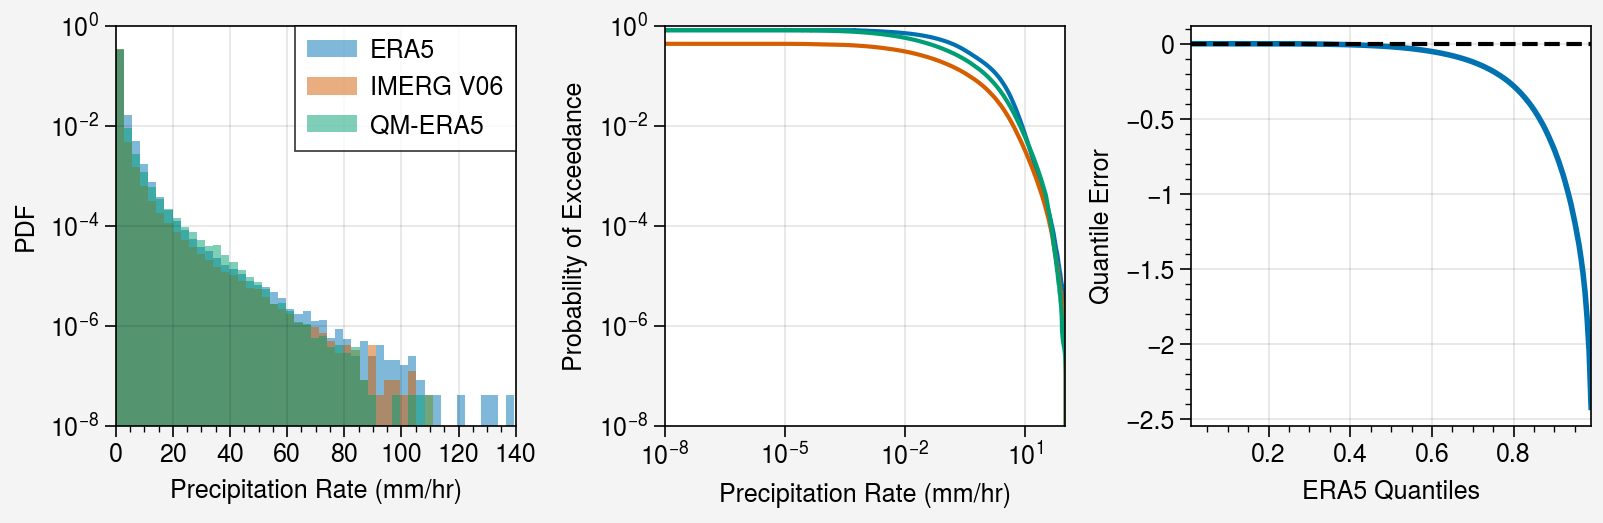

In [7]:
era5flat,imergflat = flatten(era5,imerg)
qm     = fit_empirical_qm(era5flat,imergflat)
mapped = qm(era5flat)

plot_distributions(era5flat,imergflat,mapped)

In [ ]:
plot_qm_sensitivity(era5flat,imergflat)
pplt.show()
# fig.save('../figs/fig_S3.jpg')